# 06 - Forecasting Models

**Purpose:** compare baselines and Random Forest models for two tasks:

- next-month review-count regression;
- attention-pulse classification.

The main comparison is whether SNA and NLP features add useful signal beyond time-series history and business metadata.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
METRICS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_metrics.csv"
PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_predictions.csv"
PULSE_METRICS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_metrics.csv"
PULSE_PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_predictions.csv"

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
modeling = pd.read_csv(FORECASTING_DATASET_PATH)
business_lookup = pd.read_csv(COHORT_BUSINESSES_PATH)[["business_id", "name", "categories"]]
print(modeling.shape)
modeling.head()

(95533, 57)


,business_id,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,...,recent_text_avg_stars,feature_month_str,target_month_str,calendar_month,month_sin,month_cos,feature_month_number,pulse_baseline_reviews,pulse_relative_lift,attention_pulse
0,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,2015-01,2015-02,1,0.500000,8.660254e-01,1,0.0,0.0,0
1,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,2015-02,2015-03,2,0.866025,5.000000e-01,2,0.0,0.0,0
2,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,2015-03,2015-04,3,1.000000,6.123234e-17,3,0.0,0.0,0
3,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,2015-04,2015-05,4,0.866025,-5.000000e-01,4,0.0,0.0,0
4,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,2015-05,2015-06,5,0.500000,-8.660254e-01,5,0.0,0.0,0


In [2]:
def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    return np.nan if denominator == 0 else np.sum(np.abs(y_true - y_pred)) / denominator

def safe_auc(metric_fn, y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return metric_fn(y_true, score)

def evaluate_regression(split_name, model_name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        "split": split_name,
        "task": "review_count_regression",
        "model": model_name,
        "rows": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "WAPE": wape(y_true, y_pred),
    }

def evaluate_classification(split_name, model_name, y_true, y_pred, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    return {
        "split": split_name,
        "task": "attention_pulse_classification",
        "model": model_name,
        "rows": len(y_true),
        "positive_rate": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": safe_auc(roc_auc_score, y_true, y_score),
        "PR_AUC": safe_auc(average_precision_score, y_true, y_score),
    }

splits = {
    "primary_covid_test": {"train_start": "2015-02", "train_end": "2019-12", "test_start": "2020-01", "test_end": "2021-12"},
    "secondary_pre_covid_test": {"train_start": "2015-02", "train_end": "2018-12", "test_start": "2019-01", "test_end": "2019-12"},
}

historical_features = ["prev_month_reviews", "rolling_3_avg", "rolling_6_avg", "same_month_previous_year", "cumulative_review_count", "avg_rating_history", "calendar_month", "month_sin", "month_cos", "feature_month_number"]
business_features = ["business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]
static_sna_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]
dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]
sna_features = static_sna_features + dynamic_social_exposure_features
nlp_features = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
]

feature_sets = {
    "ML: historical": historical_features,
    "ML: historical + business": historical_features + business_features,
    "ML: historical + SNA": historical_features + sna_features,
    "ML: historical + NLP": historical_features + nlp_features,
    "ML: all modalities": historical_features + business_features + sna_features + nlp_features,
}

required_columns = historical_features + business_features + sna_features + nlp_features + ["attention_pulse", "pulse_baseline_reviews", "pulse_relative_lift"]
missing_features = [feature for feature in required_columns if feature not in modeling.columns]
if missing_features:
    raise ValueError(f"Missing modeling features. Rerun notebook 05: {missing_features}")

In [3]:
regression_metrics = []
regression_prediction_frames = []
regression_models = {}

for split_name, split in splits.items():
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    train_df = modeling[train_mask].copy()
    test_df = modeling[test_mask].copy()
    y_train = train_df["target_next_month_reviews"].astype(float)
    y_test = test_df["target_next_month_reviews"].astype(float)

    baseline_predictions = {
        "Baseline: last month": test_df["prev_month_reviews"].values,
        "Baseline: rolling 3-month avg": test_df["rolling_3_avg"].values,
        "Baseline: seasonal naive": test_df["same_month_previous_year"].values,
    }
    for model_name, y_pred in baseline_predictions.items():
        regression_metrics.append(evaluate_regression(split_name, model_name, y_test.values, y_pred))
        regression_prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]].assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None)))

    for model_name, features in feature_sets.items():
        model = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
        model.fit(train_df[features], y_train)
        y_pred = model.predict(test_df[features])
        regression_metrics.append(evaluate_regression(split_name, model_name, y_test.values, y_pred))
        regression_prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]].assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None)))
        regression_models[(split_name, model_name)] = (model, features)

metrics_df = pd.DataFrame(regression_metrics).sort_values(["split", "WAPE", "MAE"])
predictions_df = pd.concat(regression_prediction_frames, ignore_index=True)
metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
metrics_df

,split,task,model,rows,MAE,RMSE,WAPE
0,primary_covid_test,review_count_regression,Baseline: last month,27624,1.311323,2.653812,0.688473
1,primary_covid_test,review_count_regression,Baseline: rolling 3-month avg,27624,1.342685,2.954533,0.704938
5,primary_covid_test,review_count_regression,ML: historical + SNA,27624,1.443832,2.965813,0.758043
3,primary_covid_test,review_count_regression,ML: historical,27624,1.445102,2.996562,0.758710
6,primary_covid_test,review_count_regression,ML: historical + NLP,27624,1.458281,3.009956,0.765628
7,primary_covid_test,review_count_regression,ML: all modalities,27624,1.473066,3.029931,0.773391
4,primary_covid_test,review_count_regression,ML: historical + business,27624,1.476581,3.066598,0.775237
2,primary_covid_test,review_count_regression,Baseline: seasonal naive,27624,2.877643,6.556732,1.510824
12,secondary_pre_covid_test,review_count_regression,ML: historical + business,13812,1.832381,3.111897,0.383840
15,secondary_pre_covid_test,review_count_regression,ML: all modalities,13812,1.841902,3.112665,0.385834


In [4]:
pulse_metrics = []
pulse_prediction_frames = []
pulse_models = {}

for split_name, split in splits.items():
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    train_df = modeling[train_mask].copy()
    test_df = modeling[test_mask].copy()
    y_train = train_df["attention_pulse"].astype(int)
    y_test = test_df["attention_pulse"].astype(int)

    baseline_scores = {
        "Baseline: previous-month pulse rule": (
            (test_df["prev_month_reviews"] >= 3)
            & (test_df["prev_month_reviews"] >= test_df["rolling_6_avg"] + 2)
            & (test_df["prev_month_reviews"] >= 1.5 * np.maximum(test_df["rolling_6_avg"], 1))
        ).astype(int),
        "Baseline: rising recent activity": (
            (test_df["rolling_3_avg"] > test_df["rolling_6_avg"])
            & (test_df["prev_month_reviews"] >= 3)
        ).astype(int),
    }
    for model_name, y_score in baseline_scores.items():
        y_pred = np.asarray(y_score, dtype=int)
        pulse_metrics.append(evaluate_classification(split_name, model_name, y_test.values, y_pred, y_pred))
        pulse_prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]].assign(split=split_name, model=model_name, prediction=y_pred, probability=y_pred))

    for model_name, features in feature_sets.items():
        model = RandomForestClassifier(
            n_estimators=140,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        model.fit(train_df[features], y_train)
        y_score = model.predict_proba(test_df[features])[:, 1]
        y_pred = (y_score >= 0.5).astype(int)
        pulse_metrics.append(evaluate_classification(split_name, model_name, y_test.values, y_pred, y_score))
        pulse_prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]].assign(split=split_name, model=model_name, prediction=y_pred, probability=y_score))
        pulse_models[(split_name, model_name)] = (model, features)

pulse_metrics_df = pd.DataFrame(pulse_metrics).sort_values(["split", "F1", "PR_AUC"], ascending=[True, False, False])
pulse_predictions_df = pd.concat(pulse_prediction_frames, ignore_index=True)
pulse_metrics_df.to_csv(PULSE_METRICS_OUTPUT_PATH, index=False)
pulse_predictions_df.to_csv(PULSE_PREDICTIONS_OUTPUT_PATH, index=False)
pulse_metrics_df

,split,task,model,rows,positive_rate,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
1,primary_covid_test,attention_pulse_classification,Baseline: rising recent activity,27624,0.081198,0.841189,0.218191,0.370040,0.274516,0.626433,0.131891
3,primary_covid_test,attention_pulse_classification,ML: historical + business,27624,0.081198,0.842275,0.199032,0.311636,0.242919,0.737436,0.173474
0,primary_covid_test,attention_pulse_classification,Baseline: previous-month pulse rule,27624,0.081198,0.891688,0.279056,0.210878,0.240223,0.581366,0.122922
6,primary_covid_test,attention_pulse_classification,ML: all modalities,27624,0.081198,0.860122,0.201693,0.244316,0.220968,0.742895,0.175975
2,primary_covid_test,attention_pulse_classification,ML: historical,27624,0.081198,0.853931,0.188022,0.240749,0.211144,0.719570,0.155715
5,primary_covid_test,attention_pulse_classification,ML: historical + NLP,27624,0.081198,0.852266,0.173882,0.218457,0.193638,0.710674,0.151074
4,primary_covid_test,attention_pulse_classification,ML: historical + SNA,27624,0.081198,0.875941,0.188421,0.159608,0.172822,0.722832,0.159269
10,secondary_pre_covid_test,attention_pulse_classification,ML: historical + business,13812,0.112149,0.746090,0.210184,0.458360,0.288208,0.694809,0.236460
13,secondary_pre_covid_test,attention_pulse_classification,ML: all modalities,13812,0.112149,0.768100,0.216003,0.406068,0.282000,0.685029,0.218896
12,secondary_pre_covid_test,attention_pulse_classification,ML: historical + NLP,13812,0.112149,0.721908,0.197146,0.481601,0.279767,0.682011,0.223885


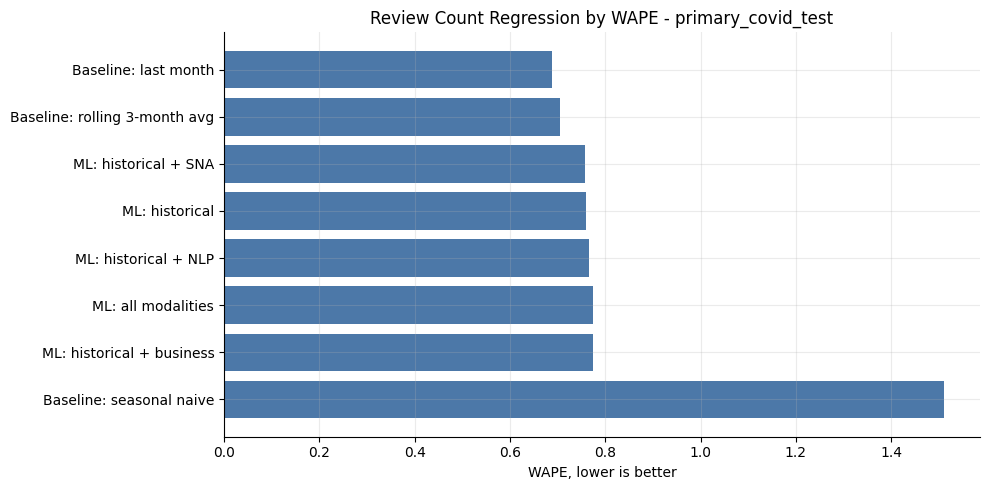

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_primary_covid_test.png


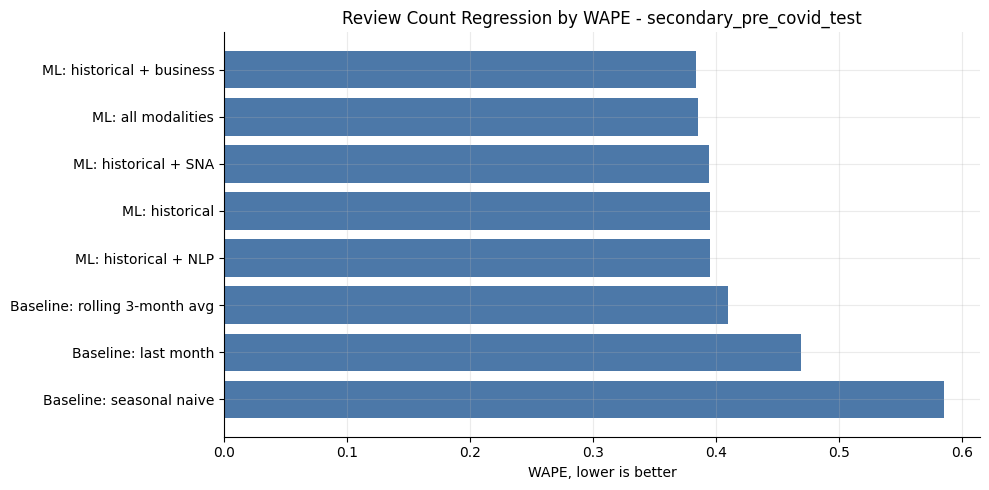

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_secondary_pre_covid_test.png


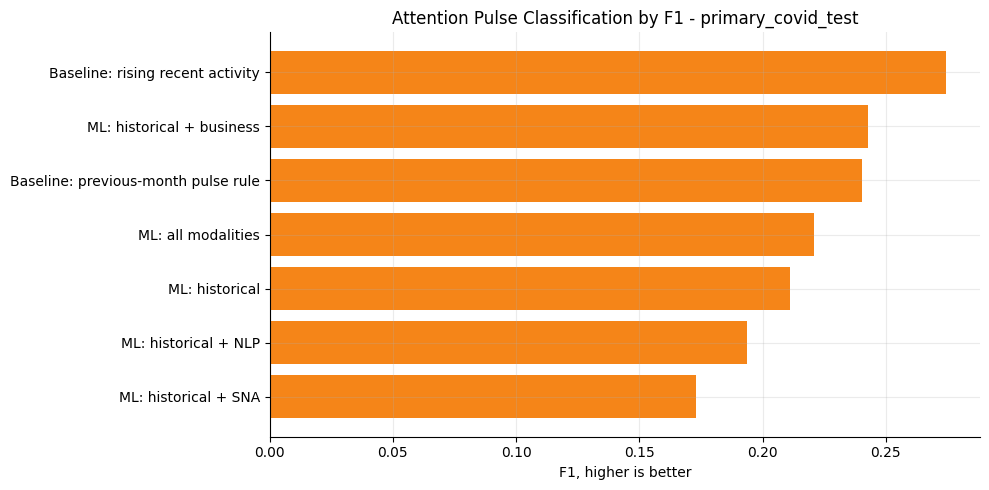

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_primary_covid_test.png


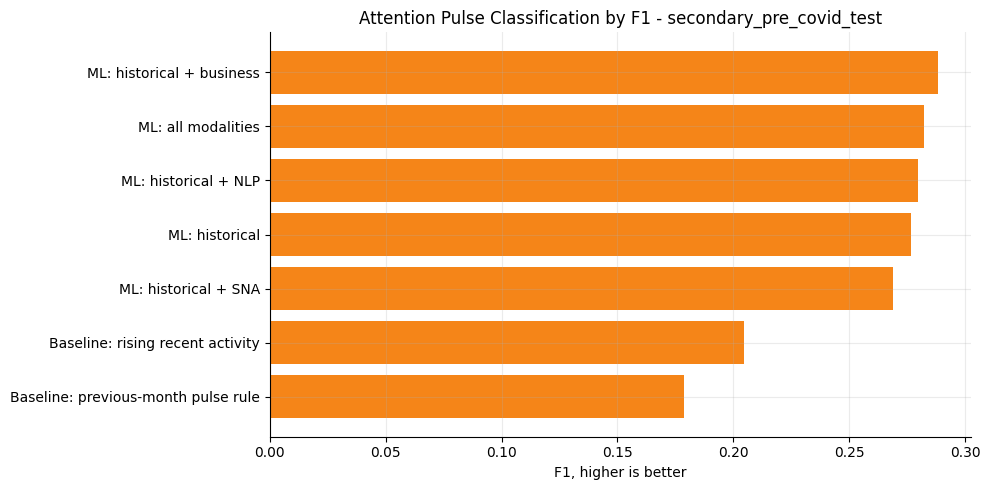

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_secondary_pre_covid_test.png


In [5]:
for split_name in metrics_df["split"].unique():
    split_metrics = metrics_df[metrics_df["split"] == split_name].sort_values("WAPE")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(split_metrics["model"], split_metrics["WAPE"], color="#4C78A8")
    ax.invert_yaxis()
    ax.set_title(f"Review Count Regression by WAPE - {split_name}")
    ax.set_xlabel("WAPE, lower is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_wape_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("F1", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(split_metrics["model"], split_metrics["F1"], color="#F58518")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Classification by F1 - {split_name}")
    ax.set_xlabel("F1, higher is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_f1_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

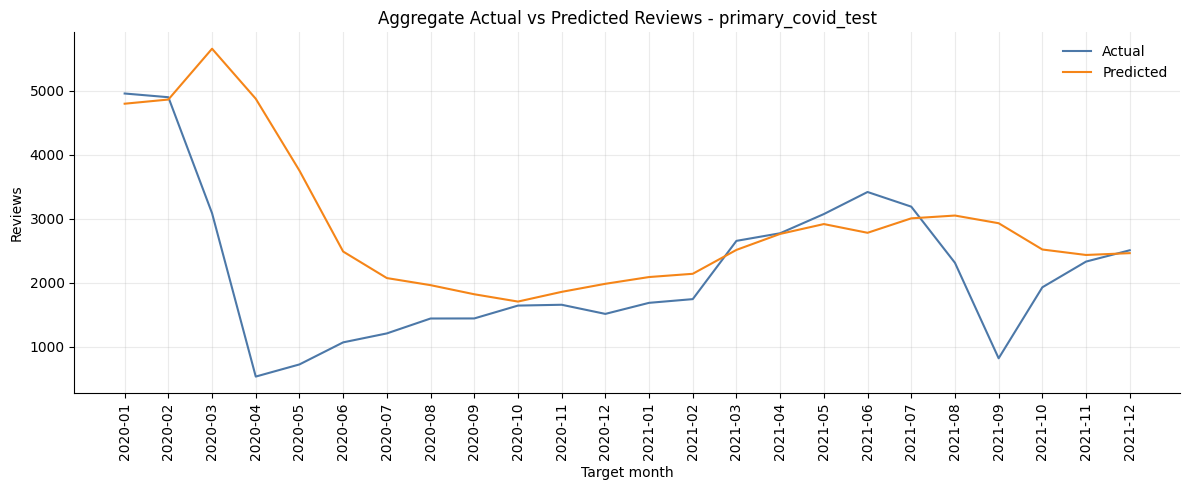

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_primary_covid_test.png


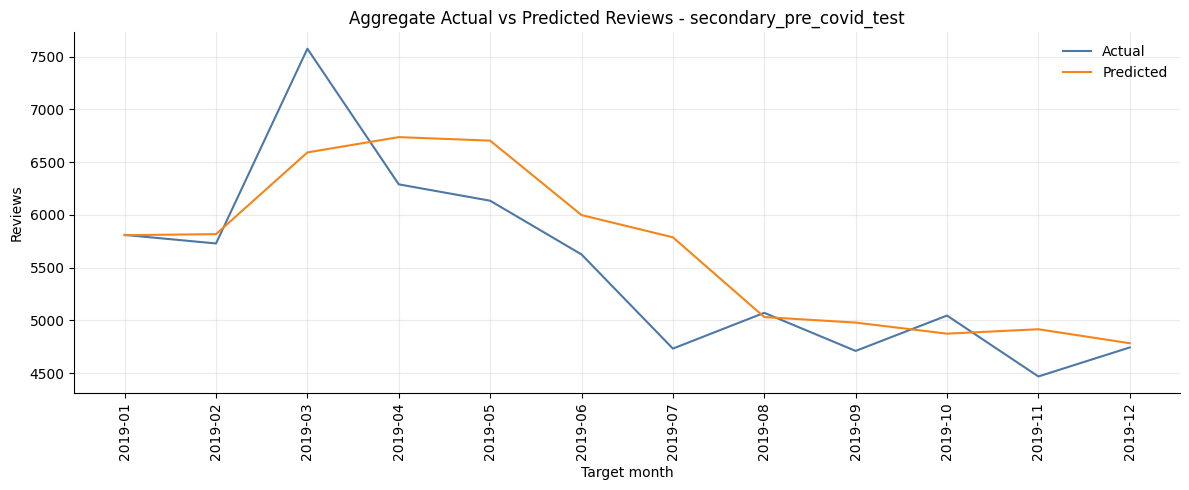

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_secondary_pre_covid_test.png


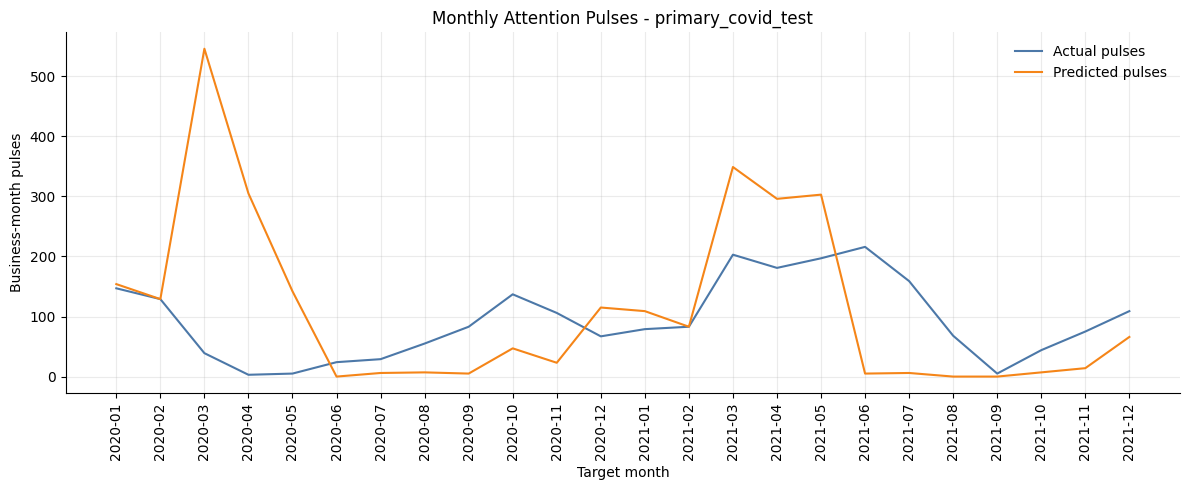

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_primary_covid_test.png


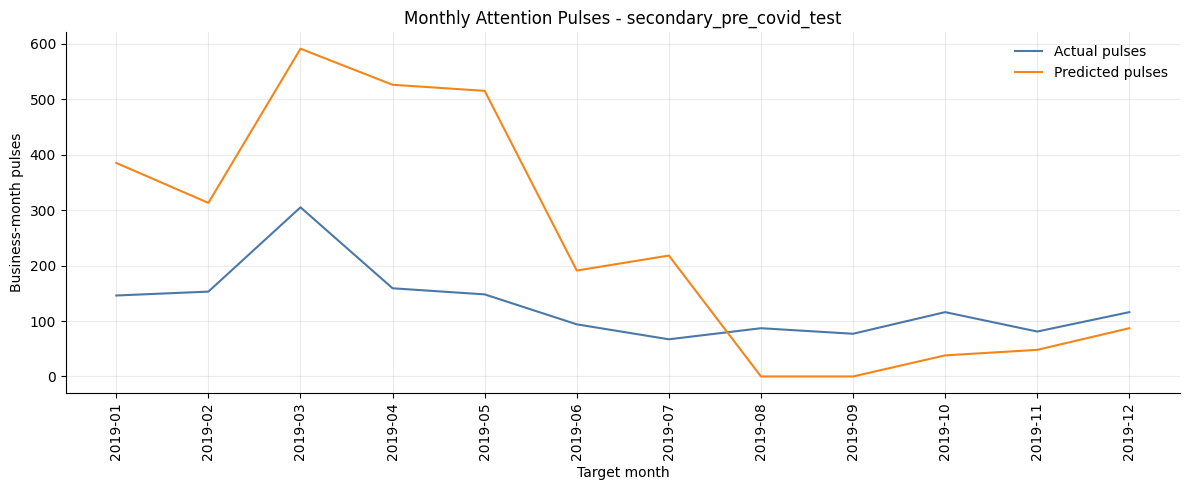

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_secondary_pre_covid_test.png


In [6]:
comparison_model = "ML: all modalities"
for split_name in predictions_df["split"].unique():
    plot_df = predictions_df[(predictions_df["split"] == split_name) & (predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual=("target_next_month_reviews", "sum"), predicted=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual"], label="Actual", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted"], label="Predicted", color="#F58518")
    ax.set_title(f"Aggregate Actual vs Predicted Reviews - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Reviews")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_predictions_df["split"].unique():
    plot_df = pulse_predictions_df[(pulse_predictions_df["split"] == split_name) & (pulse_predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual_pulses=("attention_pulse", "sum"), predicted_pulses=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual_pulses"], label="Actual pulses", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted_pulses"], label="Predicted pulses", color="#F58518")
    ax.set_title(f"Monthly Attention Pulses - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Business-month pulses")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

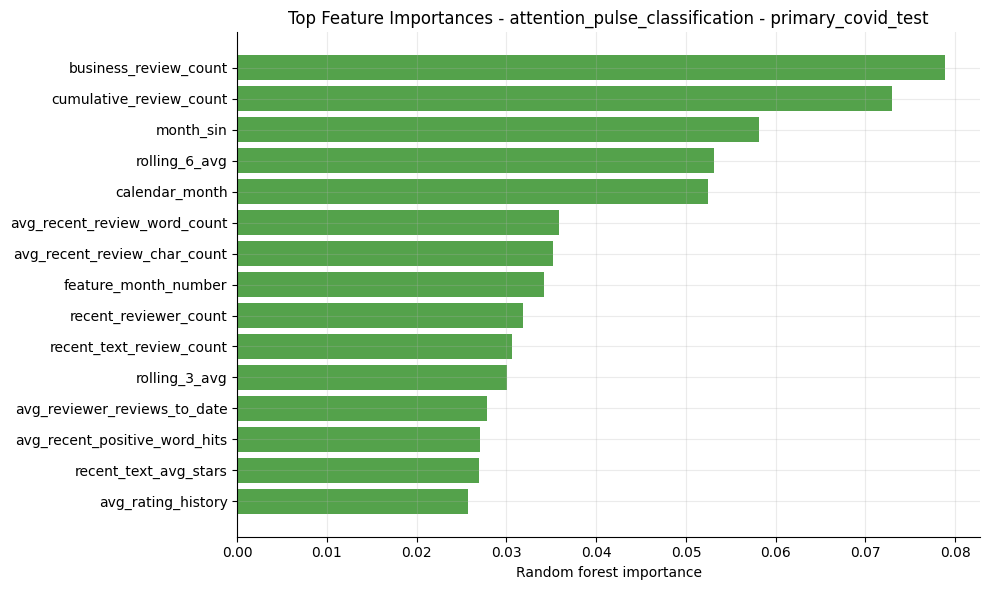

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_primary_covid_test.png


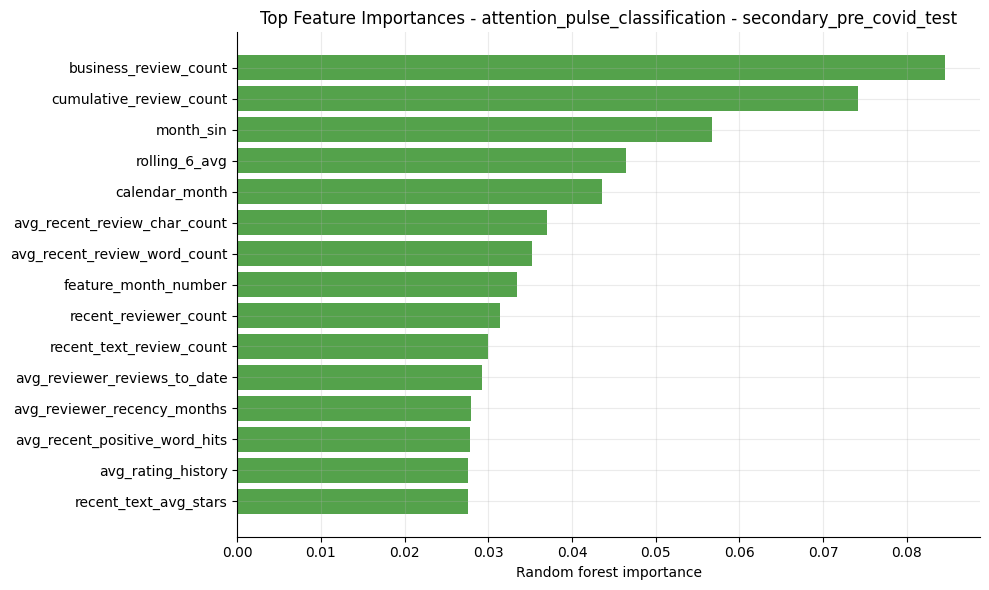

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_secondary_pre_covid_test.png


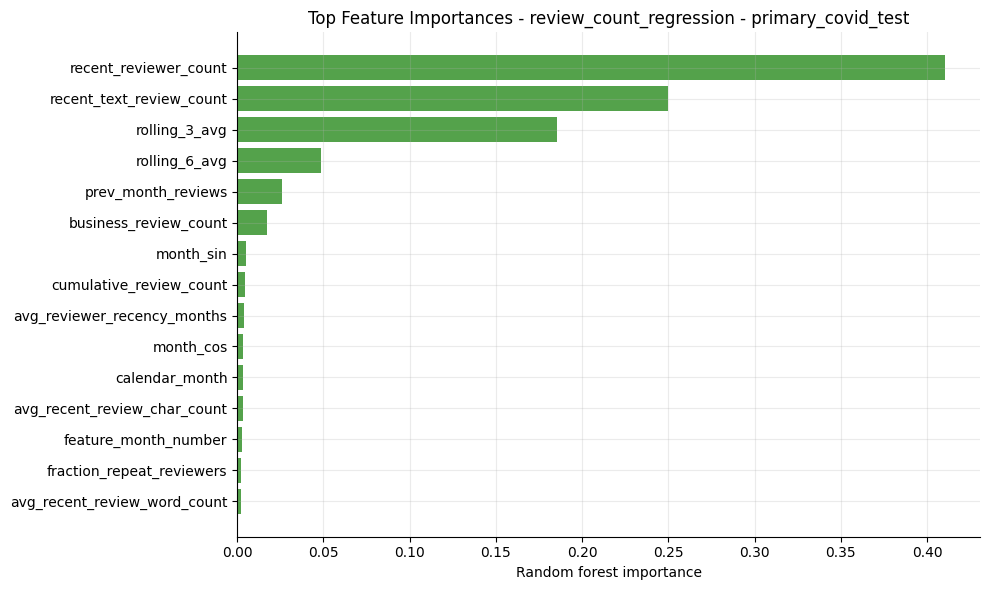

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_primary_covid_test.png


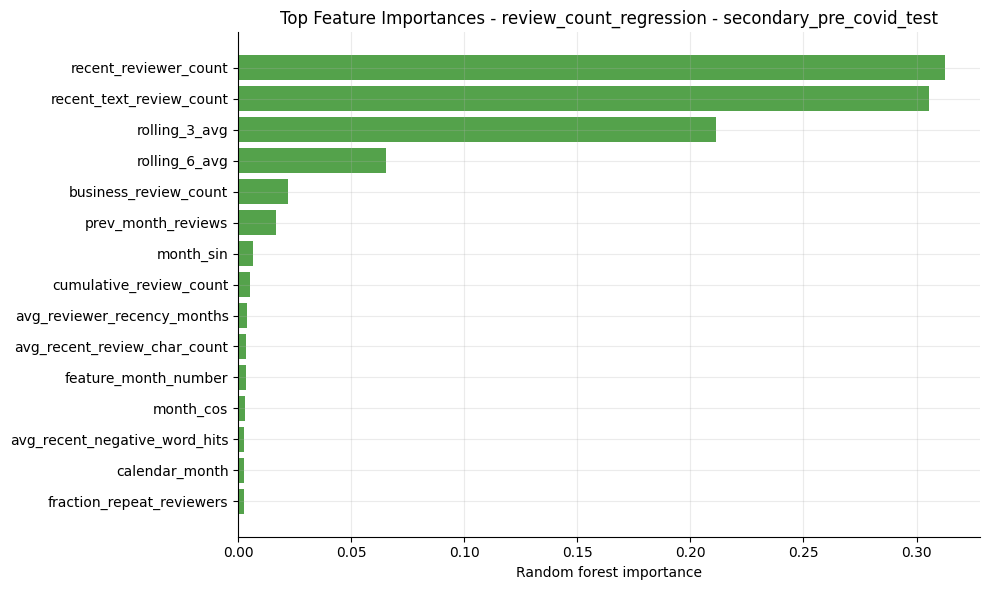

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_secondary_pre_covid_test.png


,task,split,feature,importance
105,attention_pulse_classification,primary_covid_test,business_review_count,0.078825
98,attention_pulse_classification,primary_covid_test,cumulative_review_count,0.072967
101,attention_pulse_classification,primary_covid_test,month_sin,0.058147
96,attention_pulse_classification,primary_covid_test,rolling_6_avg,0.053084
100,attention_pulse_classification,primary_covid_test,calendar_month,0.052454
135,attention_pulse_classification,primary_covid_test,avg_recent_review_word_count,0.035852
134,attention_pulse_classification,primary_covid_test,avg_recent_review_char_count,0.035167
103,attention_pulse_classification,primary_covid_test,feature_month_number,0.034200
110,attention_pulse_classification,primary_covid_test,recent_reviewer_count,0.031809
133,attention_pulse_classification,primary_covid_test,recent_text_review_count,0.030614


In [7]:
importance_rows = []
for (split_name, model_name), (model, features) in regression_models.items():
    if model_name != "ML: all modalities":
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "review_count_regression", "split": split_name, "feature": feature, "importance": importance})
for (split_name, model_name), (model, features) in pulse_models.items():
    if model_name != "ML: all modalities":
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "attention_pulse_classification", "split": split_name, "feature": feature, "importance": importance})

importance_df = pd.DataFrame(importance_rows).sort_values(["task", "split", "importance"], ascending=[True, True, False])

for (task, split_name), group in importance_df.groupby(["task", "split"]):
    top_importance = group.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_importance["feature"], top_importance["importance"], color="#54A24B")
    ax.set_title(f"Top Feature Importances - {task} - {split_name}")
    ax.set_xlabel("Random forest importance")
    fig.tight_layout()
    safe_task = task.replace("_classification", "").replace("_regression", "")
    path = FIGURES_DIR / f"{safe_task}_feature_importance_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

importance_df.head(20)

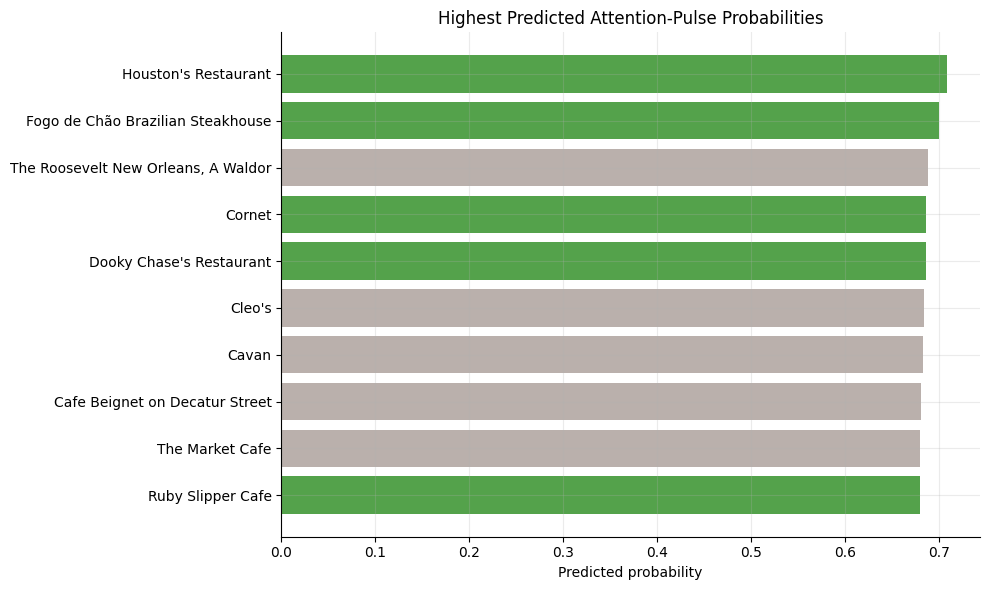

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_top_predicted_examples.png


,business_id,name,target_month_str,attention_pulse,target_next_month_reviews,pulse_baseline_reviews,pulse_relative_lift,probability
0,dbli0TD6YQfbnWTv-43KLg,Houston's Restaurant,2021-03,1,8.0,3.500000,2.285714,0.708628
1,u537LRjJmHI4eqMARsP9ng,Fogo de Chão Brazilian Steakhouse,2021-03,1,11.0,4.166667,2.640000,0.700433
2,WtVOrfqLXerig9Z7iP-NzA,"The Roosevelt New Orleans, A Waldorf Astoria H...",2020-03,0,6.0,4.333333,1.384615,0.688928
3,-s6EMVPCBrsocFDuiMMqxQ,Cornet,2021-03,1,11.0,3.333333,3.300000,0.686519
4,R9TBf8VqGQ83kvdIxkC9RQ,Dooky Chase's Restaurant,2021-04,1,9.0,3.666667,2.454545,0.686338
5,WNhcS2zi4zAqA2TbduVINQ,Cleo's,2020-04,0,0.0,3.500000,0.000000,0.684815
6,Tf_Oj8uWRvXmqkEmntzTdA,Cavan,2020-03,0,6.0,4.833333,1.241379,0.683771
7,kBgiy6ulQRiATWFPZjTPKA,Cafe Beignet on Decatur Street,2021-03,0,6.0,5.166667,1.161290,0.680777
8,ZLrqw4KCwKyBlVqycUfNbg,The Market Cafe,2020-03,0,3.0,3.666667,0.818182,0.680082
9,nePr9450kf-eEGYD-Qn21w,Ruby Slipper Cafe,2021-03,1,10.0,5.166667,1.935484,0.679714


In [8]:
example_split = "primary_covid_test"
example_model = "ML: all modalities"
examples = (
    pulse_predictions_df[(pulse_predictions_df["split"] == example_split) & (pulse_predictions_df["model"] == example_model)]
    .sort_values("probability", ascending=False)
    .head(10)
    .merge(business_lookup, on="business_id", how="left")
)

fig, ax = plt.subplots(figsize=(10, 6))
labels = examples["name"].fillna(examples["business_id"]).str.slice(0, 35)
colors = np.where(examples["attention_pulse"].eq(1), "#54A24B", "#BAB0AC")
ax.barh(labels[::-1], examples["probability"].values[::-1], color=colors[::-1])
ax.set_title("Highest Predicted Attention-Pulse Probabilities")
ax.set_xlabel("Predicted probability")
fig.tight_layout()
path = FIGURES_DIR / "attention_pulse_top_predicted_examples.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

examples[["business_id", "name", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift", "probability"]]

## Modeling Takeaways

- Review-count regression remains strongly driven by recent temporal activity.
- Attention-pulse classification is the more distinctive community-attention task.
- Feature ablations keep the interpretation simple: historical, business, SNA, NLP, and all modalities.
- Figures are named by task: `review_count_*` for regression and `attention_pulse_*` for classification.